# **Dijkstra's Shortest Path Algorithm for International Flights Data**

### The Twist
- We consider three different variables when searching for a route using a 3-term cost function (price of booking, flight distance, and seat class).
- We can filter flights depending on which airline(s) we would like to take; not all airlines offer flights between every location.

### Usage
1. Load the datasets from the dictionaries I've prepared earlier (or alternatively, upload `international_flights.csv`)
2. Visualise the dataset to check that it's working and has been loaded properly
3. Run Dijkstra's search algorithm (you can do this as many times as you want with however many filters you'd like!)
4. Visualise your last-generated path
5. (Optional) Run unit tests

This project uses a subset of a synthetic dataset on [Kaggle](https://www.kaggle.com/datasets/syedaeman2212/airline-ticket-prices-dataset).

## 1. Load datasets
Please run **both** of the following cells.

In [1]:
# @title **Directed dataset**
# dictionary output from parse_file
directed_journeys = {'Mumbai': {'Paris': [['Saudia', '2643', 'Economy', '555.30'], ['Flynas', '2049', 'Business', '632.42'], ['Qatar Airways', '5736', 'First', '3786.09'], ['British Airways', '5613', 'Business', '2297.97'], ['Turkish Airlines', '3857', 'Business', '1310.46'], ['Lufthansa', '10515', 'First', '5363.96'], ['Emirates', '623', 'Business', '293.77']], 'Istanbul': [['Turkish Airlines', '9382', 'First', '6495.84'], ['Etihad', '3201', 'Business', '1029.87'], ['Flynas', '10486', 'First', '3977.68'], ['Lufthansa', '951', 'Economy', '134.76'], ['Turkish Airlines', '9840', 'Economy', '2322.56'], ['Turkish Airlines', '6955', 'Business', '3467.59']], 'New York': [['Saudia', '6328', 'First', '3257.78'], ['Saudia', '4433', 'Economy', '562.73']], 'London': [['Etihad', '4319', 'Economy', '815.27'], ['Qatar Airways', '8504', 'Economy', '988.75'], ['British Airways', '1168', 'Economy', '355.78'], ['Lufthansa', '8427', 'Economy', '1792.07']], 'Cairo': [['Qatar Airways', '4434', 'Economy', '504.74'], ['Lufthansa', '11306', 'Economy', '2325.11'], ['British Airways', '8838', 'Economy', '1211.14']], 'Riyadh': [['Qatar Airways', '884', 'Business', '440.82'], ['Flynas', '10724', 'First', '6895.45']], 'Dubai': [['Qatar Airways', '6407', 'Economy', '770.28']], 'Doha': [['Lufthansa', '2274', 'Economy', '451.04']]}, 'Istanbul': {'Jeddah': [['Etihad', '8266', 'Business', '2070.27'], ['Emirates', '440', 'Economy', '185.70'], ['Qatar Airways', '11901', 'Business', '3014.65'], ['Flynas', '695', 'First', '395.88']], 'Doha': [['Turkish Airlines', '6122', 'First', '2323.31'], ['Saudia', '3516', 'Economy', '875.76']], 'New York': [['Saudia', '6192', 'Business', '2675.72'], ['Lufthansa', '5347', 'Business', '1512.77'], ['Emirates', '444', 'Business', '248.52']], 'Cairo': [['Saudia', '2880', 'Economy', '507.24'], ['Saudia', '8736', 'First', '4160.18'], ['British Airways', '4168', 'Business', '2044.55'], ['Flynas', '6704', 'Business', '2040.90'], ['Etihad', '6420', 'Economy', '1167.88']], 'Dubai': [['Qatar Airways', '11502', 'Economy', '1934.15'], ['Etihad', '6447', 'Economy', '775.55'], ['Etihad', '3445', 'First', '1417.51'], ['British Airways', '7074', 'First', '2656.31']], 'London': [['Etihad', '2201', 'Business', '532.94'], ['Qatar Airways', '4565', 'First', '1798.55']], 'Riyadh': [['Etihad', '396', 'First', '245.53'], ['Qatar Airways', '2623', 'Business', '1243.63'], ['Emirates', '3578', 'First', '1495.68']], 'Paris': [['Qatar Airways', '484', 'First', '293.25'], ['Etihad', '460', 'First', '365.36'], ['Lufthansa', '807', 'Economy', '160.57']], 'Mumbai': [['Qatar Airways', '10760', 'Economy', '2052.97'], ['Turkish Airlines', '11903', 'Economy', '2026.29'], ['Etihad', '7130', 'Business', '2026.24'], ['Emirates', '2605', 'First', '1615.37']]}, 'Dubai': {'Riyadh': [['British Airways', '2698', 'First', '1883.11'], ['Turkish Airlines', '718', 'Economy', '106.07'], ['Flynas', '9975', 'Business', '2477.71'], ['Saudia', '10709', 'Business', '5133.78']], 'New York': [['Lufthansa', '1682', 'First', '644.19'], ['Lufthansa', '2167', 'Business', '594.92'], ['Emirates', '8817', 'Economy', '2038.94'], ['Qatar Airways', '1891', 'First', '869.10'], ['Etihad', '4002', 'Business', '1066.93']], 'Paris': [['British Airways', '2652', 'Economy', '533.61'], ['Turkish Airlines', '6941', 'First', '4298.76']], 'Jeddah': [['Saudia', '6533', 'First', '4045.74'], ['Qatar Airways', '11848', 'First', '4419.58'], ['Etihad', '8402', 'Business', '2116.88']], 'London': [['Turkish Airlines', '931', 'First', '814.07']], 'Cairo': [['Emirates', '7266', 'Economy', '1058.28']], 'Mumbai': [['Qatar Airways', '4151', 'Economy', '857.60']], 'Doha': [['Qatar Airways', '1647', 'First', '804.60']]}, 'London': {'Istanbul': [['Emirates', '7956', 'First', '5349.65'], ['Emirates', '6494', 'Economy', '1593.55'], ['British Airways', '637', 'Business', '278.66'], ['Lufthansa', '7175', 'Business', '1835.17']], 'New York': [['British Airways', '1430', 'Business', '790.36'], ['Qatar Airways', '3482', 'Economy', '522.34'], ['Flynas', '2060', 'Business', '523.36'], ['Emirates', '3806', 'First', '2852.67']], 'Paris': [['British Airways', '3448', 'Economy', '863.15'], ['Turkish Airlines', '9280', 'Business', '2854.75']], 'Dubai': [['Flynas', '4101', 'First', '2912.55'], ['Emirates', '10021', 'First', '5889.12'], ['Lufthansa', '11323', 'Business', '2737.17']], 'Doha': [['Flynas', '3314', 'Business', '1198.38'], ['Emirates', '8152', 'First', '3552.64']], 'Jeddah': [['Saudia', '7499', 'Economy', '1749.77'], ['British Airways', '9263', 'First', '6473.45']], 'Cairo': [['Emirates', '8474', 'Business', '1984.74'], ['Flynas', '8149', 'Economy', '912.09'], ['British Airways', '966', 'Economy', '361.61']], 'Mumbai': [['Qatar Airways', '9400', 'Business', '2299.94'], ['Qatar Airways', '11153', 'First', '8852.69']], 'Riyadh': [['British Airways', '4772', 'Economy', '626.66'], ['Flynas', '8465', 'Economy', '1775.34'], ['Flynas', '7406', 'Business', '2915.50']]}, 'Doha': {'Dubai': [['Qatar Airways', '1308', 'Business', '516.19'], ['Emirates', '3506', 'Economy', '439.16'], ['Saudia', '6644', 'First', '2499.06'], ['Turkish Airlines', '6204', 'Business', '1501.05']], 'Cairo': [['Qatar Airways', '5589', 'Business', '1404.20'], ['Qatar Airways', '9572', 'Economy', '1485.53'], ['Saudia', '8949', 'First', '5377.31'], ['Turkish Airlines', '10409', 'First', '4295.40'], ['Lufthansa', '1463', 'First', '1073.36'], ['Turkish Airlines', '4307', 'Business', '1091.12']], 'New York': [['Qatar Airways', '10971', 'First', '7698.07'], ['Turkish Airlines', '2609', 'First', '1767.21']], 'London': [['Saudia', '5531', 'First', '3229.28'], ['Flynas', '1621', 'Economy', '380.98'], ['Qatar Airways', '6143', 'First', '4434.71'], ['Saudia', '7396', 'Business', '3008.26']], 'Istanbul': [['Flynas', '2695', 'Economy', '552.54'], ['Emirates', '7767', 'First', '3172.05'], ['British Airways', '6355', 'Business', '1616.61']], 'Riyadh': [['Lufthansa', '5802', 'Business', '1479.53'], ['Etihad', '2279', 'Economy', '306.50'], ['British Airways', '5010', 'First', '1947.50'], ['Qatar Airways', '376', 'Business', '281.79']], 'Jeddah': [['Turkish Airlines', '11773', 'Business', '3758.74'], ['British Airways', '10590', 'First', '6803.82']], 'Paris': [['Etihad', '4413', 'Business', '1069.93']], 'Mumbai': [['Flynas', '6188', 'First', '2396.76']]}, 'Paris': {'Riyadh': [['Qatar Airways', '7150', 'Business', '3032.38'], ['Emirates', '11720', 'Business', '4168.67'], ['Saudia', '11094', 'First', '4174.01']], 'London': [['Saudia', '3864', 'First', '2895.64'], ['Qatar Airways', '11511', 'Business', '3274.89'], ['Emirates', '9472', 'First', '3519.14']], 'Dubai': [['Lufthansa', '9731', 'First', '7601.00'], ['Lufthansa', '2068', 'Economy', '354.70'], ['Qatar Airways', '2970', 'Business', '817.76'], ['Emirates', '10595', 'Economy', '1298.37'], ['British Airways', '2224', 'First', '1005.86']], 'Doha': [['British Airways', '8180', 'Business', '3088.65'], ['Emirates', '10255', 'Business', '2392.13'], ['Etihad', '6019', 'First', '2247.61']], 'Istanbul': [['Emirates', '3605', 'Economy', '844.79'], ['Lufthansa', '4452', 'Business', '2267.18'], ['Saudia', '7129', 'First', '3316.60'], ['Turkish Airlines', '6948', 'First', '3648.54'], ['British Airways', '7993', 'Economy', '1204.97']], 'Cairo': [['Turkish Airlines', '11328', 'Business', '2704.53'], ['Flynas', '2607', 'Economy', '382.22'], ['Lufthansa', '1888', 'First', '1030.10'], ['Etihad', '1602', 'Business', '824.72'], ['Saudia', '9160', 'Economy', '2045.27']], 'New York': [['Turkish Airlines', '9950', 'Economy', '1407.07'], ['Lufthansa', '9628', 'Economy', '1825.15'], ['Emirates', '11507', 'Economy', '1525.2']], 'Jeddah': [['Emirates', '2186', 'First', '1135.92']], 'Mumbai': [['Qatar Airways', '9012', 'First', '5367.82']]}, 'New York': {'Jeddah': [['Flynas', '3760', 'First', '2282.17'], ['Emirates', '5881', 'Economy', '1086.89'], ['British Airways', '10446', 'Business', '3975.44']], 'Mumbai': [['Turkish Airlines', '5573', 'Business', '1334.79'], ['Emirates', '8561', 'Economy', '1001.00']], 'Riyadh': [['Lufthansa', '11244', 'Economy', '1929.27'], ['British Airways', '3485', 'Economy', '498.29'], ['Lufthansa', '7370', 'Business', '1783.66']], 'Istanbul': [['Qatar Airways', '2817', 'Business', '682.12'], ['Emirates', '9282', 'Economy', '1142.37'], ['Saudia', '8125', 'Business', '4032.71']], 'London': [['Lufthansa', '10010', 'Business', '3606.08'], ['British Airways', '903', 'First', '614.55']], 'Doha': [['Lufthansa', '11300', 'First', '8559.08'], ['Saudia', '10818', 'Economy', '2227.96']], 'Dubai': [['Lufthansa', '804', 'First', '650.83']], 'Paris': [['Flynas', '7324', 'Economy', '921.18'], ['Emirates', '8104', 'Economy', '916.41']], 'Cairo': [['British Airways', '5059', 'Business', '2536.28'], ['Qatar Airways', '3900', 'Economy', '916.82'], ['Etihad', '11384', 'Economy', '2472.36']]}, 'Jeddah': {'Cairo': [['Lufthansa', '5492', 'Business', '2210.16'], ['Qatar Airways', '6879', 'First', '2555.85'], ['Lufthansa', '8292', 'Economy', '905.78'], ['Turkish Airlines', '2974', 'Economy', '393.39'], ['Saudia', '4205', 'Economy', '742.15'], ['Etihad', '4154', 'First', '1554.41']], 'London': [['Saudia', '6248', 'Business', '1613.13'], ['Flynas', '3101', 'First', '1444.13'], ['Saudia', '2927', 'Economy', '373.53']], 'Istanbul': [['Etihad', '9267', 'First', '5746.40'], ['Turkish Airlines', '5677', 'Economy', '717.41'], ['Flynas', '7532', 'Economy', '981.05']], 'Paris': [['British Airways', '8451', 'First', '6581.19'], ['Turkish Airlines', '636', 'First', '372.85']], 'Doha': [['Saudia', '965', 'Economy', '287.58'], ['Lufthansa', '6188', 'Business', '2445.98'], ['Turkish Airlines', '336', 'First', '275.34']], 'Dubai': [['British Airways', '10236', 'Economy', '2284.29']], 'Riyadh': [['Flynas', '2829', 'Business', '821.38'], ['Flynas', '9316', 'Economy', '1315.64']]}, 'Riyadh': {'Mumbai': [['Saudia', '7444', 'First', '2807.81'], ['Etihad', '3075', 'Economy', '631.08'], ['Turkish Airlines', '1548', 'First', '935.49'], ['Flynas', '1531', 'Business', '547.91'], ['Flynas', '3843', 'First', '1494.54']], 'Cairo': [['Etihad', '2533', 'Business', '876.97'], ['Turkish Airlines', '10682', 'Economy', '2392.27']], 'Dubai': [['British Airways', '10297', 'Economy', '1234.43'], ['Flynas', '7895', 'Business', '1895.91'], ['Lufthansa', '11626', 'Economy', '1537.27']], 'Paris': [['Qatar Airways', '471', 'First', '280.23'], ['British Airways', '8616', 'Business', '2085.04'], ['Turkish Airlines', '7345', 'Economy', '848.01'], ['Turkish Airlines', '9699', 'First', '6071.56']], 'New York': [['Emirates', '3696', 'Economy', '907.58'], ['British Airways', '9279', 'First', '3485.76'], ['Flynas', '11551', 'Economy', '1374.01']], 'Istanbul': [['Saudia', '2195', 'Economy', '425.61'], ['Emirates', '8765', 'Economy', '1486.51'], ['Lufthansa', '8028', 'Business', '2540.92']], 'Doha': [['Lufthansa', '7826', 'First', '5264.14']], 'Jeddah': [['Saudia', '5058', 'First', '2398.78']]}, 'Cairo': {'Istanbul': [['Emirates', '10191', 'Business', '4532.22'], ['Etihad', '6998', 'Economy', '1677.98'], ['Etihad', '8201', 'Business', '2009.24']], 'Doha': [['Lufthansa', '4586', 'Economy', '711.26'], ['British Airways', '10371', 'Economy', '1268.99']], 'Mumbai': [['Qatar Airways', '4258', 'First', '2073.14'], ['Lufthansa', '543', 'First', '425.98']], 'Paris': [['Qatar Airways', '5031', 'Economy', '597.50'], ['Saudia', '5301', 'Economy', '696.06'], ['Qatar Airways', '3733', 'First', '2110.31']], 'Riyadh': [['Lufthansa', '4239', 'Economy', '942.15'], ['Etihad', '11081', 'Business', '2627.88'], ['British Airways', '4918', 'Economy', '584.62'], ['Saudia', '11771', 'Business', '2789.98'], ['Lufthansa', '6952', 'First', '2601.86']], 'Jeddah': [['Saudia', '5106', 'First', '2720.95']], 'London': [['Saudia', '4529', 'Business', '1883.93']], 'Dubai': [['Turkish Airlines', '3045', 'First', '1226.63']], 'New York': [['Emirates', '8903', 'Economy', '1120.52']]}}

In [2]:
# @title **Undirected dataset**
# dictionary output from parse_file
undirected_journeys = {'Mumbai': {'Paris': [['Saudia', '2643', 'Economy', '555.30'], ['Flynas', '2049', 'Business', '632.42'], ['Qatar Airways', '5736', 'First', '3786.09'], ['British Airways', '5613', 'Business', '2297.97'], ['Turkish Airlines', '3857', 'Business', '1310.46'], ['Qatar Airways', '9012', 'First', '5367.82'], ['Lufthansa', '10515', 'First', '5363.96'], ['Emirates', '623', 'Business', '293.77']], 'Istanbul': [['Turkish Airlines', '9382', 'First', '6495.84'], ['Etihad', '3201', 'Business', '1029.87'], ['Flynas', '10486', 'First', '3977.68'], ['Lufthansa', '951', 'Economy', '134.76'], ['Qatar Airways', '10760', 'Economy', '2052.97'], ['Turkish Airlines', '11903', 'Economy', '2026.29'], ['Etihad', '7130', 'Business', '2026.24'], ['Emirates', '2605', 'First', '1615.37'], ['Turkish Airlines', '9840', 'Economy', '2322.56'], ['Turkish Airlines', '6955', 'Business', '3467.59']], 'New York': [['Saudia', '6328', 'First', '3257.78'], ['Turkish Airlines', '5573', 'Business', '1334.79'], ['Emirates', '8561', 'Economy', '1001.00'], ['Saudia', '4433', 'Economy', '562.73']], 'Riyadh': [['Saudia', '7444', 'First', '2807.81'], ['Etihad', '3075', 'Economy', '631.08'], ['Qatar Airways', '884', 'Business', '440.82'], ['Turkish Airlines', '1548', 'First', '935.49'], ['Flynas', '1531', 'Business', '547.91'], ['Flynas', '3843', 'First', '1494.54'], ['Flynas', '10724', 'First', '6895.45']], 'London': [['Etihad', '4319', 'Economy', '815.27'], ['Qatar Airways', '8504', 'Economy', '988.75'], ['British Airways', '1168', 'Economy', '355.78'], ['Lufthansa', '8427', 'Economy', '1792.07'], ['Qatar Airways', '9400', 'Business', '2299.94'], ['Qatar Airways', '11153', 'First', '8852.69']], 'Cairo': [['Qatar Airways', '4434', 'Economy', '504.74'], ['Qatar Airways', '4258', 'First', '2073.14'], ['Lufthansa', '11306', 'Economy', '2325.11'], ['British Airways', '8838', 'Economy', '1211.14'], ['Lufthansa', '543', 'First', '425.98']], 'Dubai': [['Qatar Airways', '4151', 'Economy', '857.60'], ['Qatar Airways', '6407', 'Economy', '770.28']], 'Doha': [['Lufthansa', '2274', 'Economy', '451.04'], ['Flynas', '6188', 'First', '2396.76']]}, 'Paris': {'Mumbai': [['Saudia', '2643', 'Economy', '555.30'], ['Flynas', '2049', 'Business', '632.42'], ['Qatar Airways', '5736', 'First', '3786.09'], ['British Airways', '5613', 'Business', '2297.97'], ['Turkish Airlines', '3857', 'Business', '1310.46'], ['Qatar Airways', '9012', 'First', '5367.82'], ['Lufthansa', '10515', 'First', '5363.96'], ['Emirates', '623', 'Business', '293.77']], 'Riyadh': [['Qatar Airways', '7150', 'Business', '3032.38'], ['Qatar Airways', '471', 'First', '280.23'], ['British Airways', '8616', 'Business', '2085.04'], ['Turkish Airlines', '7345', 'Economy', '848.01'], ['Emirates', '11720', 'Business', '4168.67'], ['Saudia', '11094', 'First', '4174.01'], ['Turkish Airlines', '9699', 'First', '6071.56']], 'London': [['Saudia', '3864', 'First', '2895.64'], ['British Airways', '3448', 'Economy', '863.15'], ['Qatar Airways', '11511', 'Business', '3274.89'], ['Emirates', '9472', 'First', '3519.14'], ['Turkish Airlines', '9280', 'Business', '2854.75']], 'Dubai': [['Lufthansa', '9731', 'First', '7601.00'], ['British Airways', '2652', 'Economy', '533.61'], ['Lufthansa', '2068', 'Economy', '354.70'], ['Qatar Airways', '2970', 'Business', '817.76'], ['Emirates', '10595', 'Economy', '1298.37'], ['British Airways', '2224', 'First', '1005.86'], ['Turkish Airlines', '6941', 'First', '4298.76']], 'Doha': [['British Airways', '8180', 'Business', '3088.65'], ['Emirates', '10255', 'Business', '2392.13'], ['Etihad', '4413', 'Business', '1069.93'], ['Etihad', '6019', 'First', '2247.61']], 'Istanbul': [['Emirates', '3605', 'Economy', '844.79'], ['Lufthansa', '4452', 'Business', '2267.18'], ['Saudia', '7129', 'First', '3316.60'], ['Qatar Airways', '484', 'First', '293.25'], ['Turkish Airlines', '6948', 'First', '3648.54'], ['Etihad', '460', 'First', '365.36'], ['Lufthansa', '807', 'Economy', '160.57'], ['British Airways', '7993', 'Economy', '1204.97']], 'Jeddah': [['British Airways', '8451', 'First', '6581.19'], ['Emirates', '2186', 'First', '1135.92'], ['Turkish Airlines', '636', 'First', '372.85']], 'Cairo': [['Turkish Airlines', '11328', 'Business', '2704.53'], ['Qatar Airways', '5031', 'Economy', '597.50'], ['Flynas', '2607', 'Economy', '382.22'], ['Lufthansa', '1888', 'First', '1030.10'], ['Saudia', '5301', 'Economy', '696.06'], ['Etihad', '1602', 'Business', '824.72'], ['Saudia', '9160', 'Economy', '2045.27'], ['Qatar Airways', '3733', 'First', '2110.31']], 'New York': [['Turkish Airlines', '9950', 'Economy', '1407.07'], ['Flynas', '7324', 'Economy', '921.18'], ['Emirates', '8104', 'Economy', '916.41'], ['Lufthansa', '9628', 'Economy', '1825.15'], ['Emirates', '11507', 'Economy', '1525.2']]}, 'Istanbul': {'Jeddah': [['Etihad', '8266', 'Business', '2070.27'], ['Emirates', '440', 'Economy', '185.70'], ['Etihad', '9267', 'First', '5746.40'], ['Turkish Airlines', '5677', 'Economy', '717.41'], ['Qatar Airways', '11901', 'Business', '3014.65'], ['Flynas', '7532', 'Economy', '981.05'], ['Flynas', '695', 'First', '395.88']], 'London': [['Emirates', '7956', 'First', '5349.65'], ['Etihad', '2201', 'Business', '532.94'], ['Emirates', '6494', 'Economy', '1593.55'], ['Qatar Airways', '4565', 'First', '1798.55'], ['British Airways', '637', 'Business', '278.66'], ['Lufthansa', '7175', 'Business', '1835.17']], 'Mumbai': [['Turkish Airlines', '9382', 'First', '6495.84'], ['Etihad', '3201', 'Business', '1029.87'], ['Flynas', '10486', 'First', '3977.68'], ['Lufthansa', '951', 'Economy', '134.76'], ['Qatar Airways', '10760', 'Economy', '2052.97'], ['Turkish Airlines', '11903', 'Economy', '2026.29'], ['Etihad', '7130', 'Business', '2026.24'], ['Emirates', '2605', 'First', '1615.37'], ['Turkish Airlines', '9840', 'Economy', '2322.56'], ['Turkish Airlines', '6955', 'Business', '3467.59']], 'Doha': [['Turkish Airlines', '6122', 'First', '2323.31'], ['Flynas', '2695', 'Economy', '552.54'], ['Emirates', '7767', 'First', '3172.05'], ['British Airways', '6355', 'Business', '1616.61'], ['Saudia', '3516', 'Economy', '875.76']], 'New York': [['Saudia', '6192', 'Business', '2675.72'], ['Qatar Airways', '2817', 'Business', '682.12'], ['Emirates', '9282', 'Economy', '1142.37'], ['Saudia', '8125', 'Business', '4032.71'], ['Lufthansa', '5347', 'Business', '1512.77'], ['Emirates', '444', 'Business', '248.52']], 'Cairo': [['Saudia', '2880', 'Economy', '507.24'], ['Emirates', '10191', 'Business', '4532.22'], ['Etihad', '6998', 'Economy', '1677.98'], ['Saudia', '8736', 'First', '4160.18'], ['Etihad', '8201', 'Business', '2009.24'], ['British Airways', '4168', 'Business', '2044.55'], ['Flynas', '6704', 'Business', '2040.90'], ['Etihad', '6420', 'Economy', '1167.88']], 'Paris': [['Emirates', '3605', 'Economy', '844.79'], ['Lufthansa', '4452', 'Business', '2267.18'], ['Saudia', '7129', 'First', '3316.60'], ['Qatar Airways', '484', 'First', '293.25'], ['Turkish Airlines', '6948', 'First', '3648.54'], ['Etihad', '460', 'First', '365.36'], ['Lufthansa', '807', 'Economy', '160.57'], ['British Airways', '7993', 'Economy', '1204.97']], 'Dubai': [['Qatar Airways', '11502', 'Economy', '1934.15'], ['Etihad', '6447', 'Economy', '775.55'], ['Etihad', '3445', 'First', '1417.51'], ['British Airways', '7074', 'First', '2656.31']], 'Riyadh': [['Etihad', '396', 'First', '245.53'], ['Qatar Airways', '2623', 'Business', '1243.63'], ['Saudia', '2195', 'Economy', '425.61'], ['Emirates', '8765', 'Economy', '1486.51'], ['Emirates', '3578', 'First', '1495.68'], ['Lufthansa', '8028', 'Business', '2540.92']]}, 'Jeddah': {'Istanbul': [['Etihad', '8266', 'Business', '2070.27'], ['Emirates', '440', 'Economy', '185.70'], ['Etihad', '9267', 'First', '5746.40'], ['Turkish Airlines', '5677', 'Economy', '717.41'], ['Qatar Airways', '11901', 'Business', '3014.65'], ['Flynas', '7532', 'Economy', '981.05'], ['Flynas', '695', 'First', '395.88']], 'New York': [['Flynas', '3760', 'First', '2282.17'], ['Emirates', '5881', 'Economy', '1086.89'], ['British Airways', '10446', 'Business', '3975.44']], 'Cairo': [['Lufthansa', '5492', 'Business', '2210.16'], ['Qatar Airways', '6879', 'First', '2555.85'], ['Lufthansa', '8292', 'Economy', '905.78'], ['Turkish Airlines', '2974', 'Economy', '393.39'], ['Saudia', '5106', 'First', '2720.95'], ['Saudia', '4205', 'Economy', '742.15'], ['Etihad', '4154', 'First', '1554.41']], 'London': [['Saudia', '6248', 'Business', '1613.13'], ['Flynas', '3101', 'First', '1444.13'], ['Saudia', '7499', 'Economy', '1749.77'], ['Saudia', '2927', 'Economy', '373.53'], ['British Airways', '9263', 'First', '6473.45']], 'Paris': [['British Airways', '8451', 'First', '6581.19'], ['Emirates', '2186', 'First', '1135.92'], ['Turkish Airlines', '636', 'First', '372.85']], 'Dubai': [['Saudia', '6533', 'First', '4045.74'], ['British Airways', '10236', 'Economy', '2284.29'], ['Qatar Airways', '11848', 'First', '4419.58'], ['Etihad', '8402', 'Business', '2116.88']], 'Doha': [['Saudia', '965', 'Economy', '287.58'], ['Lufthansa', '6188', 'Business', '2445.98'], ['Turkish Airlines', '11773', 'Business', '3758.74'], ['Turkish Airlines', '336', 'First', '275.34'], ['British Airways', '10590', 'First', '6803.82']], 'Riyadh': [['Flynas', '2829', 'Business', '821.38'], ['Flynas', '9316', 'Economy', '1315.64'], ['Saudia', '5058', 'First', '2398.78']]}, 'Dubai': {'Riyadh': [['British Airways', '2698', 'First', '1883.11'], ['British Airways', '10297', 'Economy', '1234.43'], ['Turkish Airlines', '718', 'Economy', '106.07'], ['Flynas', '7895', 'Business', '1895.91'], ['Flynas', '9975', 'Business', '2477.71'], ['Saudia', '10709', 'Business', '5133.78'], ['Lufthansa', '11626', 'Economy', '1537.27']], 'Doha': [['Qatar Airways', '1308', 'Business', '516.19'], ['Emirates', '3506', 'Economy', '439.16'], ['Saudia', '6644', 'First', '2499.06'], ['Qatar Airways', '1647', 'First', '804.60'], ['Turkish Airlines', '6204', 'Business', '1501.05']], 'Paris': [['Lufthansa', '9731', 'First', '7601.00'], ['British Airways', '2652', 'Economy', '533.61'], ['Lufthansa', '2068', 'Economy', '354.70'], ['Qatar Airways', '2970', 'Business', '817.76'], ['Emirates', '10595', 'Economy', '1298.37'], ['British Airways', '2224', 'First', '1005.86'], ['Turkish Airlines', '6941', 'First', '4298.76']], 'New York': [['Lufthansa', '1682', 'First', '644.19'], ['Lufthansa', '804', 'First', '650.83'], ['Lufthansa', '2167', 'Business', '594.92'], ['Emirates', '8817', 'Economy', '2038.94'], ['Qatar Airways', '1891', 'First', '869.10'], ['Etihad', '4002', 'Business', '1066.93']], 'Istanbul': [['Qatar Airways', '11502', 'Economy', '1934.15'], ['Etihad', '6447', 'Economy', '775.55'], ['Etihad', '3445', 'First', '1417.51'], ['British Airways', '7074', 'First', '2656.31']], 'London': [['Flynas', '4101', 'First', '2912.55'], ['Turkish Airlines', '931', 'First', '814.07'], ['Emirates', '10021', 'First', '5889.12'], ['Lufthansa', '11323', 'Business', '2737.17']], 'Jeddah': [['Saudia', '6533', 'First', '4045.74'], ['British Airways', '10236', 'Economy', '2284.29'], ['Qatar Airways', '11848', 'First', '4419.58'], ['Etihad', '8402', 'Business', '2116.88']], 'Cairo': [['Emirates', '7266', 'Economy', '1058.28'], ['Turkish Airlines', '3045', 'First', '1226.63']], 'Mumbai': [['Qatar Airways', '4151', 'Economy', '857.60'], ['Qatar Airways', '6407', 'Economy', '770.28']]}, 'Riyadh': {'Dubai': [['British Airways', '2698', 'First', '1883.11'], ['British Airways', '10297', 'Economy', '1234.43'], ['Turkish Airlines', '718', 'Economy', '106.07'], ['Flynas', '7895', 'Business', '1895.91'], ['Flynas', '9975', 'Business', '2477.71'], ['Saudia', '10709', 'Business', '5133.78'], ['Lufthansa', '11626', 'Economy', '1537.27']], 'Paris': [['Qatar Airways', '7150', 'Business', '3032.38'], ['Qatar Airways', '471', 'First', '280.23'], ['British Airways', '8616', 'Business', '2085.04'], ['Turkish Airlines', '7345', 'Economy', '848.01'], ['Emirates', '11720', 'Business', '4168.67'], ['Saudia', '11094', 'First', '4174.01'], ['Turkish Airlines', '9699', 'First', '6071.56']], 'New York': [['Lufthansa', '11244', 'Economy', '1929.27'], ['Emirates', '3696', 'Economy', '907.58'], ['British Airways', '3485', 'Economy', '498.29'], ['British Airways', '9279', 'First', '3485.76'], ['Flynas', '11551', 'Economy', '1374.01'], ['Lufthansa', '7370', 'Business', '1783.66']], 'Mumbai': [['Saudia', '7444', 'First', '2807.81'], ['Etihad', '3075', 'Economy', '631.08'], ['Qatar Airways', '884', 'Business', '440.82'], ['Turkish Airlines', '1548', 'First', '935.49'], ['Flynas', '1531', 'Business', '547.91'], ['Flynas', '3843', 'First', '1494.54'], ['Flynas', '10724', 'First', '6895.45']], 'Cairo': [['Etihad', '2533', 'Business', '876.97'], ['Lufthansa', '4239', 'Economy', '942.15'], ['Etihad', '11081', 'Business', '2627.88'], ['British Airways', '4918', 'Economy', '584.62'], ['Saudia', '11771', 'Business', '2789.98'], ['Lufthansa', '6952', 'First', '2601.86'], ['Turkish Airlines', '10682', 'Economy', '2392.27']], 'Istanbul': [['Etihad', '396', 'First', '245.53'], ['Qatar Airways', '2623', 'Business', '1243.63'], ['Saudia', '2195', 'Economy', '425.61'], ['Emirates', '8765', 'Economy', '1486.51'], ['Emirates', '3578', 'First', '1495.68'], ['Lufthansa', '8028', 'Business', '2540.92']], 'Doha': [['Lufthansa', '5802', 'Business', '1479.53'], ['Etihad', '2279', 'Economy', '306.50'], ['British Airways', '5010', 'First', '1947.50'], ['Lufthansa', '7826', 'First', '5264.14'], ['Qatar Airways', '376', 'Business', '281.79']], 'London': [['British Airways', '4772', 'Economy', '626.66'], ['Flynas', '8465', 'Economy', '1775.34'], ['Flynas', '7406', 'Business', '2915.50']], 'Jeddah': [['Flynas', '2829', 'Business', '821.38'], ['Flynas', '9316', 'Economy', '1315.64'], ['Saudia', '5058', 'First', '2398.78']]}, 'London': {'Istanbul': [['Emirates', '7956', 'First', '5349.65'], ['Etihad', '2201', 'Business', '532.94'], ['Emirates', '6494', 'Economy', '1593.55'], ['Qatar Airways', '4565', 'First', '1798.55'], ['British Airways', '637', 'Business', '278.66'], ['Lufthansa', '7175', 'Business', '1835.17']], 'Paris': [['Saudia', '3864', 'First', '2895.64'], ['British Airways', '3448', 'Economy', '863.15'], ['Qatar Airways', '11511', 'Business', '3274.89'], ['Emirates', '9472', 'First', '3519.14'], ['Turkish Airlines', '9280', 'Business', '2854.75']], 'New York': [['British Airways', '1430', 'Business', '790.36'], ['Lufthansa', '10010', 'Business', '3606.08'], ['Qatar Airways', '3482', 'Economy', '522.34'], ['Flynas', '2060', 'Business', '523.36'], ['Emirates', '3806', 'First', '2852.67'], ['British Airways', '903', 'First', '614.55']], 'Jeddah': [['Saudia', '6248', 'Business', '1613.13'], ['Flynas', '3101', 'First', '1444.13'], ['Saudia', '7499', 'Economy', '1749.77'], ['Saudia', '2927', 'Economy', '373.53'], ['British Airways', '9263', 'First', '6473.45']], 'Mumbai': [['Etihad', '4319', 'Economy', '815.27'], ['Qatar Airways', '8504', 'Economy', '988.75'], ['British Airways', '1168', 'Economy', '355.78'], ['Lufthansa', '8427', 'Economy', '1792.07'], ['Qatar Airways', '9400', 'Business', '2299.94'], ['Qatar Airways', '11153', 'First', '8852.69']], 'Doha': [['Saudia', '5531', 'First', '3229.28'], ['Flynas', '1621', 'Economy', '380.98'], ['Flynas', '3314', 'Business', '1198.38'], ['Qatar Airways', '6143', 'First', '4434.71'], ['Emirates', '8152', 'First', '3552.64'], ['Saudia', '7396', 'Business', '3008.26']], 'Dubai': [['Flynas', '4101', 'First', '2912.55'], ['Turkish Airlines', '931', 'First', '814.07'], ['Emirates', '10021', 'First', '5889.12'], ['Lufthansa', '11323', 'Business', '2737.17']], 'Cairo': [['Emirates', '8474', 'Business', '1984.74'], ['Saudia', '4529', 'Business', '1883.93'], ['Flynas', '8149', 'Economy', '912.09'], ['British Airways', '966', 'Economy', '361.61']], 'Riyadh': [['British Airways', '4772', 'Economy', '626.66'], ['Flynas', '8465', 'Economy', '1775.34'], ['Flynas', '7406', 'Business', '2915.50']]}, 'Doha': {'Dubai': [['Qatar Airways', '1308', 'Business', '516.19'], ['Emirates', '3506', 'Economy', '439.16'], ['Saudia', '6644', 'First', '2499.06'], ['Qatar Airways', '1647', 'First', '804.60'], ['Turkish Airlines', '6204', 'Business', '1501.05']], 'Istanbul': [['Turkish Airlines', '6122', 'First', '2323.31'], ['Flynas', '2695', 'Economy', '552.54'], ['Emirates', '7767', 'First', '3172.05'], ['British Airways', '6355', 'Business', '1616.61'], ['Saudia', '3516', 'Economy', '875.76']], 'Cairo': [['Qatar Airways', '5589', 'Business', '1404.20'], ['Qatar Airways', '9572', 'Economy', '1485.53'], ['Lufthansa', '4586', 'Economy', '711.26'], ['Saudia', '8949', 'First', '5377.31'], ['Turkish Airlines', '10409', 'First', '4295.40'], ['British Airways', '10371', 'Economy', '1268.99'], ['Lufthansa', '1463', 'First', '1073.36'], ['Turkish Airlines', '4307', 'Business', '1091.12']], 'New York': [['Qatar Airways', '10971', 'First', '7698.07'], ['Lufthansa', '11300', 'First', '8559.08'], ['Saudia', '10818', 'Economy', '2227.96'], ['Turkish Airlines', '2609', 'First', '1767.21']], 'London': [['Saudia', '5531', 'First', '3229.28'], ['Flynas', '1621', 'Economy', '380.98'], ['Flynas', '3314', 'Business', '1198.38'], ['Qatar Airways', '6143', 'First', '4434.71'], ['Emirates', '8152', 'First', '3552.64'], ['Saudia', '7396', 'Business', '3008.26']], 'Paris': [['British Airways', '8180', 'Business', '3088.65'], ['Emirates', '10255', 'Business', '2392.13'], ['Etihad', '4413', 'Business', '1069.93'], ['Etihad', '6019', 'First', '2247.61']], 'Jeddah': [['Saudia', '965', 'Economy', '287.58'], ['Lufthansa', '6188', 'Business', '2445.98'], ['Turkish Airlines', '11773', 'Business', '3758.74'], ['Turkish Airlines', '336', 'First', '275.34'], ['British Airways', '10590', 'First', '6803.82']], 'Riyadh': [['Lufthansa', '5802', 'Business', '1479.53'], ['Etihad', '2279', 'Economy', '306.50'], ['British Airways', '5010', 'First', '1947.50'], ['Lufthansa', '7826', 'First', '5264.14'], ['Qatar Airways', '376', 'Business', '281.79']], 'Mumbai': [['Lufthansa', '2274', 'Economy', '451.04'], ['Flynas', '6188', 'First', '2396.76']]}, 'New York': {'Jeddah': [['Flynas', '3760', 'First', '2282.17'], ['Emirates', '5881', 'Economy', '1086.89'], ['British Airways', '10446', 'Business', '3975.44']], 'Mumbai': [['Saudia', '6328', 'First', '3257.78'], ['Turkish Airlines', '5573', 'Business', '1334.79'], ['Emirates', '8561', 'Economy', '1001.00'], ['Saudia', '4433', 'Economy', '562.73']], 'Riyadh': [['Lufthansa', '11244', 'Economy', '1929.27'], ['Emirates', '3696', 'Economy', '907.58'], ['British Airways', '3485', 'Economy', '498.29'], ['British Airways', '9279', 'First', '3485.76'], ['Flynas', '11551', 'Economy', '1374.01'], ['Lufthansa', '7370', 'Business', '1783.66']], 'Doha': [['Qatar Airways', '10971', 'First', '7698.07'], ['Lufthansa', '11300', 'First', '8559.08'], ['Saudia', '10818', 'Economy', '2227.96'], ['Turkish Airlines', '2609', 'First', '1767.21']], 'London': [['British Airways', '1430', 'Business', '790.36'], ['Lufthansa', '10010', 'Business', '3606.08'], ['Qatar Airways', '3482', 'Economy', '522.34'], ['Flynas', '2060', 'Business', '523.36'], ['Emirates', '3806', 'First', '2852.67'], ['British Airways', '903', 'First', '614.55']], 'Istanbul': [['Saudia', '6192', 'Business', '2675.72'], ['Qatar Airways', '2817', 'Business', '682.12'], ['Emirates', '9282', 'Economy', '1142.37'], ['Saudia', '8125', 'Business', '4032.71'], ['Lufthansa', '5347', 'Business', '1512.77'], ['Emirates', '444', 'Business', '248.52']], 'Dubai': [['Lufthansa', '1682', 'First', '644.19'], ['Lufthansa', '804', 'First', '650.83'], ['Lufthansa', '2167', 'Business', '594.92'], ['Emirates', '8817', 'Economy', '2038.94'], ['Qatar Airways', '1891', 'First', '869.10'], ['Etihad', '4002', 'Business', '1066.93']], 'Paris': [['Turkish Airlines', '9950', 'Economy', '1407.07'], ['Flynas', '7324', 'Economy', '921.18'], ['Emirates', '8104', 'Economy', '916.41'], ['Lufthansa', '9628', 'Economy', '1825.15'], ['Emirates', '11507', 'Economy', '1525.2']], 'Cairo': [['British Airways', '5059', 'Business', '2536.28'], ['Qatar Airways', '3900', 'Economy', '916.82'], ['Etihad', '11384', 'Economy', '2472.36'], ['Emirates', '8903', 'Economy', '1120.52']]}, 'Cairo': {'Doha': [['Qatar Airways', '5589', 'Business', '1404.20'], ['Qatar Airways', '9572', 'Economy', '1485.53'], ['Lufthansa', '4586', 'Economy', '711.26'], ['Saudia', '8949', 'First', '5377.31'], ['Turkish Airlines', '10409', 'First', '4295.40'], ['British Airways', '10371', 'Economy', '1268.99'], ['Lufthansa', '1463', 'First', '1073.36'], ['Turkish Airlines', '4307', 'Business', '1091.12']], 'Jeddah': [['Lufthansa', '5492', 'Business', '2210.16'], ['Qatar Airways', '6879', 'First', '2555.85'], ['Lufthansa', '8292', 'Economy', '905.78'], ['Turkish Airlines', '2974', 'Economy', '393.39'], ['Saudia', '5106', 'First', '2720.95'], ['Saudia', '4205', 'Economy', '742.15'], ['Etihad', '4154', 'First', '1554.41']], 'Riyadh': [['Etihad', '2533', 'Business', '876.97'], ['Lufthansa', '4239', 'Economy', '942.15'], ['Etihad', '11081', 'Business', '2627.88'], ['British Airways', '4918', 'Economy', '584.62'], ['Saudia', '11771', 'Business', '2789.98'], ['Lufthansa', '6952', 'First', '2601.86'], ['Turkish Airlines', '10682', 'Economy', '2392.27']], 'Istanbul': [['Saudia', '2880', 'Economy', '507.24'], ['Emirates', '10191', 'Business', '4532.22'], ['Etihad', '6998', 'Economy', '1677.98'], ['Saudia', '8736', 'First', '4160.18'], ['Etihad', '8201', 'Business', '2009.24'], ['British Airways', '4168', 'Business', '2044.55'], ['Flynas', '6704', 'Business', '2040.90'], ['Etihad', '6420', 'Economy', '1167.88']], 'Mumbai': [['Qatar Airways', '4434', 'Economy', '504.74'], ['Qatar Airways', '4258', 'First', '2073.14'], ['Lufthansa', '11306', 'Economy', '2325.11'], ['British Airways', '8838', 'Economy', '1211.14'], ['Lufthansa', '543', 'First', '425.98']], 'Paris': [['Turkish Airlines', '11328', 'Business', '2704.53'], ['Qatar Airways', '5031', 'Economy', '597.50'], ['Flynas', '2607', 'Economy', '382.22'], ['Lufthansa', '1888', 'First', '1030.10'], ['Saudia', '5301', 'Economy', '696.06'], ['Etihad', '1602', 'Business', '824.72'], ['Saudia', '9160', 'Economy', '2045.27'], ['Qatar Airways', '3733', 'First', '2110.31']], 'Dubai': [['Emirates', '7266', 'Economy', '1058.28'], ['Turkish Airlines', '3045', 'First', '1226.63']], 'London': [['Emirates', '8474', 'Business', '1984.74'], ['Saudia', '4529', 'Business', '1883.93'], ['Flynas', '8149', 'Economy', '912.09'], ['British Airways', '966', 'Economy', '361.61']], 'New York': [['British Airways', '5059', 'Business', '2536.28'], ['Qatar Airways', '3900', 'Economy', '916.82'], ['Etihad', '11384', 'Economy', '2472.36'], ['Emirates', '8903', 'Economy', '1120.52']]}}

Or, if you want, you can upload a file instead. However, I would suggest just using the datasets I prepared earlier.

Note: the filename must be `international_flights.csv` to prevent errors!

In [3]:
# @title *Parse data from a `.csv` file*
# @markdown (Not recommended)

from google.colab import files

def insert_into_flights(dictionary: dict, key: str, value: str, content: list):
    if key in dictionary.keys():
        if value in dictionary[key].keys(): dictionary[key][value].append(content)
        else: dictionary[key][value] = [content]
    else: dictionary[key] = {value: [content]}
    return dictionary

def parse_file(filepath: str, undirected: bool = False):
    """
    Constructs .csv file into dictionary for pathfinding.

    args:
        filepath (string):  location of international_flights.csv file
    """
    journeys = dict()
    with open(filepath, "r") as f:
        lines = f.readlines()
        for line in lines:
            line = line.split(",")
            origin, destination = line[1], line[2]
            content = [line[0], line[3], line[4], line[5][:-1]]
            # ensure graph is undirected
            journeys = insert_into_flights(journeys, origin, destination, content)
            if undirected: journeys = insert_into_flights(journeys, destination, origin, content)
        return journeys

uploaded = files.upload()
if "international_flights.csv" not in uploaded.keys():
    print("Invalid file uploaded")
else:
    directed_journeys = parse_file("international_flights.csv")
    undirected_journeys = parse_file("international_flights.csv", True)
    print("File successfully parsed")

Saving international_flights.csv to international_flights.csv
File successfully parsed


## 2. Visualise dataset networks
Run the following visualisations to check that the datasets have been imported correctly. You can use these to compare how dense each of the connection graphs is for each airline, which can help you make decisions about which airlines to filter your routing queries by.

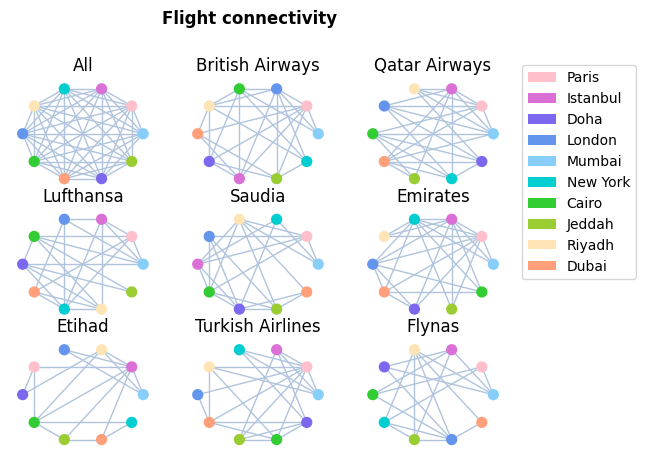

In [4]:
# @title **Flight connectivity**
# @markdown Visualise the different undirected edges between airport nodes
# @markdown depending on the airline.
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# constants
AIRLINE_NAMES = ("British Airways", "Qatar Airways", "Lufthansa", "Saudia",
                 "Emirates", "Etihad", "Turkish Airlines", "Flynas")
COLOUR = {"Paris": "pink", "Istanbul": "orchid", "Doha": "mediumslateblue",
          "London": "cornflowerblue", "Mumbai": "lightskyblue",
          "New York": "darkturquoise", "Cairo": "limegreen",
          "Jeddah": "yellowgreen", "Riyadh": "moccasin", "Dubai": "lightsalmon"}

# init figure
fig, ax = plt.subplots(3, 3)
graphs = [nx.Graph() for i in range(9)]
# add edges to graph
for loc0 in undirected_journeys.keys():
    for loc1 in undirected_journeys[loc0].keys():
        graphs[0].add_edge(loc0, loc1)
        airlines = [x[0] for x in undirected_journeys[loc0][loc1]]
        for i, carrier in enumerate(AIRLINE_NAMES):
            if carrier in airlines: graphs[i+1].add_edge(loc0, loc1)
# get node colours
colours = [[COLOUR[node] for node in graphs[i].nodes] for i in range(9)]

# plot
titles = [["All", "British Airways", "Qatar Airways"],
          ["Lufthansa", "Saudia", "Emirates"],
          ["Etihad", "Turkish Airlines", "Flynas"]]
for i in range(3):
    for j in range(3):
        nx.draw_circular(graphs[i*3 + j], ax=ax[i][j],
                         node_color=colours[i*3 + j],
                         edge_color="lightsteelblue", node_size=50)
        ax[i][j].set_title(titles[i][j])
legend_handles = [Patch(facecolor=colour, label=airport)
                  for airport, colour in COLOUR.items()]
plt.legend(handles=legend_handles, loc="lower center",
           bbox_to_anchor=(1.5, 1.5))
fig.suptitle("Flight connectivity", fontweight="bold", y=1.025)
plt.show()

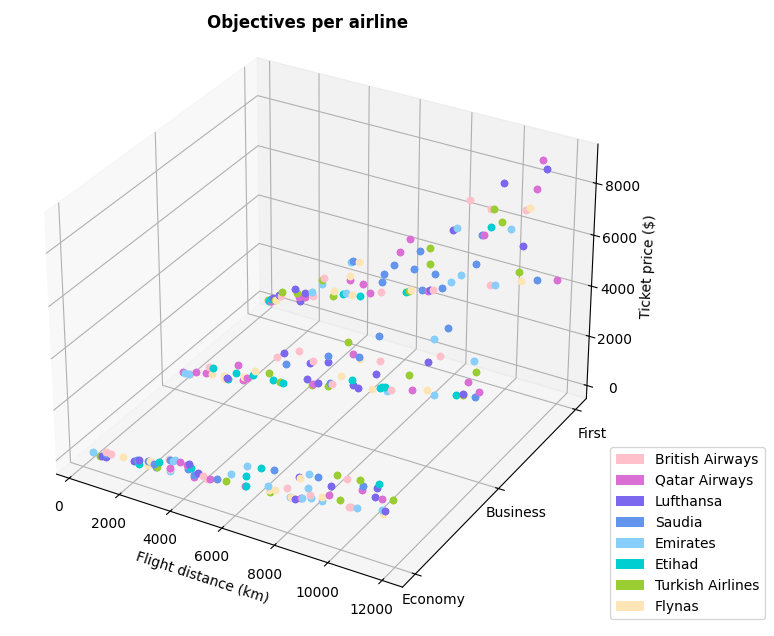

In [5]:
# @title **Airline objectives**
# @markdown Visualise the different possible combinations of each variable
# @markdown depending on the airline.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# constants
COLOUR = {"British Airways": "pink", "Qatar Airways": "orchid",
          "Lufthansa": "mediumslateblue", "Saudia": "cornflowerblue",
          "Emirates": "lightskyblue", "Etihad": "darkturquoise",
          "Turkish Airlines": "yellowgreen", "Flynas": "moccasin"}
CLASSES = {"Economy": 0, "Business": 1, "First": 2}

# init figure
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection="3d")
# plot data
for source, dictionary in undirected_journeys.items():
    for destination, flights in dictionary.items():
        for (airline, distance, flight_class, price) in flights:
            ax.scatter(int(distance), CLASSES[flight_class], float(price),
                       c=COLOUR[airline])
# format axes
ax.set_xlabel("Flight distance (km)")
ax.set_zlabel("Ticket price ($)")
ax.set_yticks([0,1,2])
ax.set_yticklabels(CLASSES.keys())
legend_handles = [Patch(facecolor=colour, label=airport)
                  for airport, colour in COLOUR.items()]
plt.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(1.1, 0))
fig.suptitle("Objectives per airline", fontweight="bold", y=0.875)
plt.show()

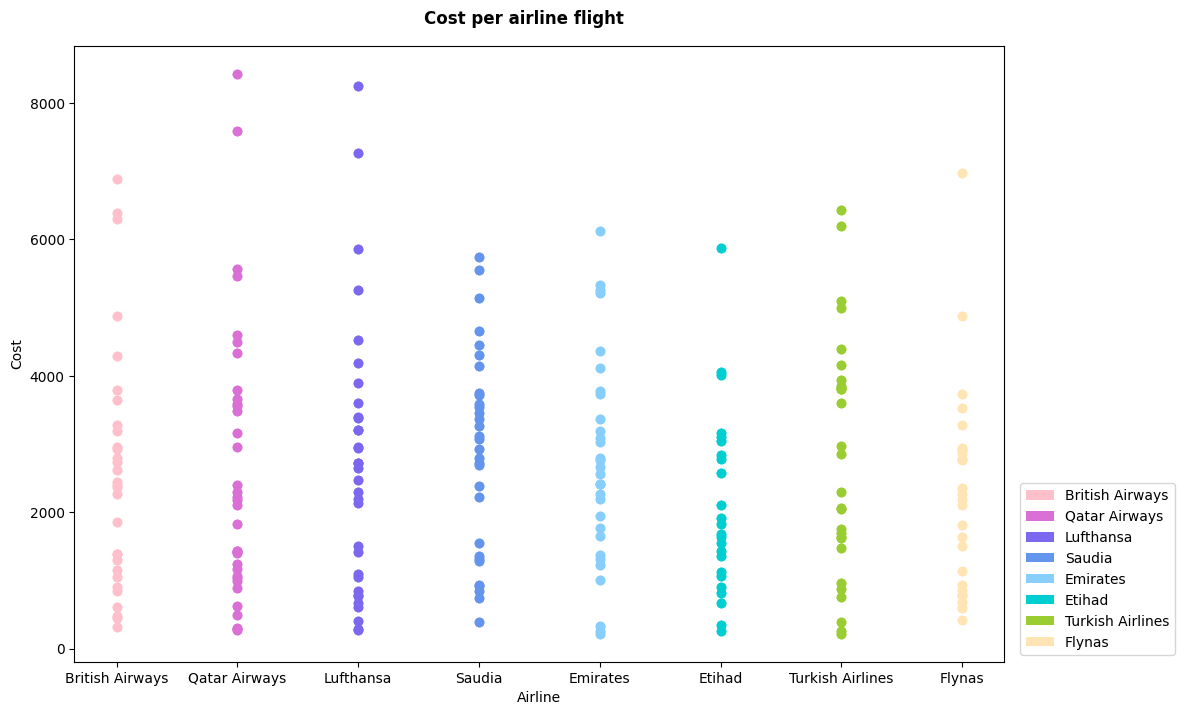

In [8]:
# @title **Airline costs**
# @markdown Visualise the different flight cost ranges for each airline.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from sys import maxsize as MAX_INT

# constants
COLOUR = {"British Airways": "pink", "Qatar Airways": "orchid",
          "Lufthansa": "mediumslateblue", "Saudia": "cornflowerblue",
          "Emirates": "lightskyblue", "Etihad": "darkturquoise",
          "Turkish Airlines": "yellowgreen", "Flynas": "moccasin"}
class_mapping = {"Economy": 0.9, "Business": 0.1, "First": 0.0}
ALPHA = 0.2
BETA = 0.1
GAMMA = 0.7
assert ALPHA + BETA + GAMMA == 1.0

# functions
def cost_function(distance, flight_class, price):
    return (ALPHA*distance +
            BETA*float(class_mapping[flight_class]) +
            GAMMA*price)

def calculate_cost(options: list[list[str]], restriction: list
                   ) -> tuple[str | None, float]:
    """
    Calculates cost of a given edge.

    args:
        options (list):     metadata associated with edge
        restriction (list): airline restrictions

    returns:
        min_cost (tuple):   minimum cost of that edge found in dataset
    """
    min_cost = (None, MAX_INT)
    for (airline, dist, flight, price) in options:
        if airline in restriction:
            cost = cost_function(float(dist), flight, float(price))
            if cost < min_cost[1]: min_cost = (airline, cost)
    return min_cost

# init figure
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot()
# plot data
for source, dictionary in undirected_journeys.items():
    for destination, flights in dictionary.items():
        for options in flights:
            cost = calculate_cost([options],list(COLOUR.keys()))
            ax.scatter(list(COLOUR.keys()).index(cost[0]), cost[1],
                       c=COLOUR[cost[0]])
# format axes
ax.set_xlabel("Airline")
ax.set_xticks(np.arange(0,8))
ax.set_xticklabels(list(COLOUR.keys()))
ax.set_ylabel("Cost")
legend_handles = [Patch(facecolor=colour, label=airport)
                  for airport, colour in COLOUR.items()]
plt.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(1.1, 0))
fig.suptitle("Cost per airline flight", fontweight="bold", y=0.925)
plt.show()

## 3. Run algorithm

In [11]:
# @title **Dijkstra's shortest path algorithm (with lazy loading)**
# @markdown Input a source and destination location, airline(s), and if you'd
# @markdown like to restrict the path to directed edges or not.
# @markdown
# @markdown #### **Locations**
# @markdown - Paris
# @markdown - Istanbul
# @markdown - Doha
# @markdown - London
# @markdown - Mumbai
# @markdown - New York
# @markdown - Cairo
# @markdown - Jeddah
# @markdown - Riyadh
# @markdown - Dubai
# @markdown
# @markdown #### **Airlines**
# @markdown - British Airways
# @markdown - Qatar Airways
# @markdown - Lufthansa
# @markdown - Saudia
# @markdown - Emirates
# @markdown - Etihad
# @markdown - Turkish Airlines
# @markdown - Flynas

from sys import maxsize as MAX_INT
from queue import PriorityQueue

# constants and mappings
AIRLINE_NAMES = ("British Airways", "Qatar Airways", "Lufthansa", "Saudia",
                 "Emirates", "Etihad", "Turkish Airlines", "Flynas")
locations = ("Paris", "Istanbul", "Doha", "London", "Mumbai",
             "New York", "Cairo", "Jeddah", "Riyadh", "Dubai")
class_mapping = {"Economy": 0.9, "Business": 0.1, "First": 0.0}

# weighting constants - change as desired to prioritise different things
ALPHA = 0.2
BETA = 0.1
GAMMA = 0.7
assert ALPHA + BETA + GAMMA == 1.0

# functions
def cost_function(distance, flight_class, price):
    return (ALPHA*distance +
            BETA*float(class_mapping[flight_class]) +
            GAMMA*price)

def calculate_cost(options: list[list[str]], restriction: list
                   ) -> tuple[str | None, float]:
    """
    Calculates cost of a given edge.

    args:
        options (list):     metadata associated with edge
        restriction (list): airline restrictions

    returns:
        min_cost (tuple):   minimum cost of that edge found in dataset
    """
    min_cost = (None, MAX_INT)
    for (airline, dist, flight, price) in options:
        if airline in restriction:
            cost = cost_function(float(dist), flight, float(price))
            if cost < min_cost[1]: min_cost = (airline, cost)
    return min_cost

def dijkstra_search(origin: str, destination: str, airlines: list,
                    directed: bool = True) -> tuple[list, float]:
    """
    Dijkstra's shortest path algorithm, optimised with lazy loading.

    args:
        origin (str):       origin airport
        destination (str):  destination airport
        airlines (list):    airlines to filter by
        directed (bool):    whether or not graph is directed or undirected

    returns:
        final_path (list):  final shortest path; list of strings
        cost (float):       final cost of shortest path
    """
    # init queue and variables
    journeys = directed_journeys if directed else undirected_journeys
    pq = PriorityQueue()
    pq.put((0, origin))
    visited = set()
    distances, previous, path = {origin: 0}, {origin: None}, {origin: ""}
    pos = None
    # iterative step
    while pq.qsize() > 0:
        cost, pos = pq.get()
        if pos in visited: continue
        visited.add(pos)
        if pos == destination: break
        for neighbour, options in journeys[pos].items():
            airline, step_cost = calculate_cost(options, airlines)
            if airline is None: continue
            new_cost = cost + step_cost
            if neighbour not in distances or new_cost < distances[neighbour]:
                distances[neighbour] = new_cost
                previous[neighbour] = pos
                path[neighbour] = airline
                pq.put((new_cost, neighbour))

    # backtrack to find final path
    if pos is None: raise Exception
    final_path, curr = [], destination
    while curr is not None:
        final_path.append((curr, path[curr]))
        curr = previous[curr]
    final_path.reverse()

    return final_path, distances[destination]

# get input parameters
source, destination = "", ""
while source not in locations:
    source = input("Source airport: ")
while destination not in locations or destination == source:
    destination = input("Destination airport: ")
airlines = []
while True:
    inp = input("'ALL', Airline, or enter to finish: ")
    if inp.upper() == "ALL" or (len(inp) == 0 and len(airlines) == 0):
        airlines = [_ for _ in AIRLINE_NAMES]
        break
    elif inp in AIRLINE_NAMES and inp not in airlines: airlines.append(inp)
    elif len(inp) == 0: break
    elif inp not in airlines: print("Error: Invalid airline.")
directed = False if (input("Directed? (Y/n): ") == "n") else True

try:
    path, cost = dijkstra_search(source, destination, airlines, directed)
    print(f"Path ({"directed" if directed else "undirected"}): " +
          f"{', '.join([f'{x} ({y})' for x, y in path])}")
    print(f"Total cost: {cost}")
except Exception: print(f"Error: Invalid path request (no path found).\n"
"Try undirected?")

Source airport: Dubai
Destination airport: Mumbai
'ALL', Airline, or enter to finish: 
Directed? (Y/n): n
Path (undirected): Dubai (), Riyadh (Turkish Airlines), Mumbai (Qatar Airways)
Total cost: 703.323


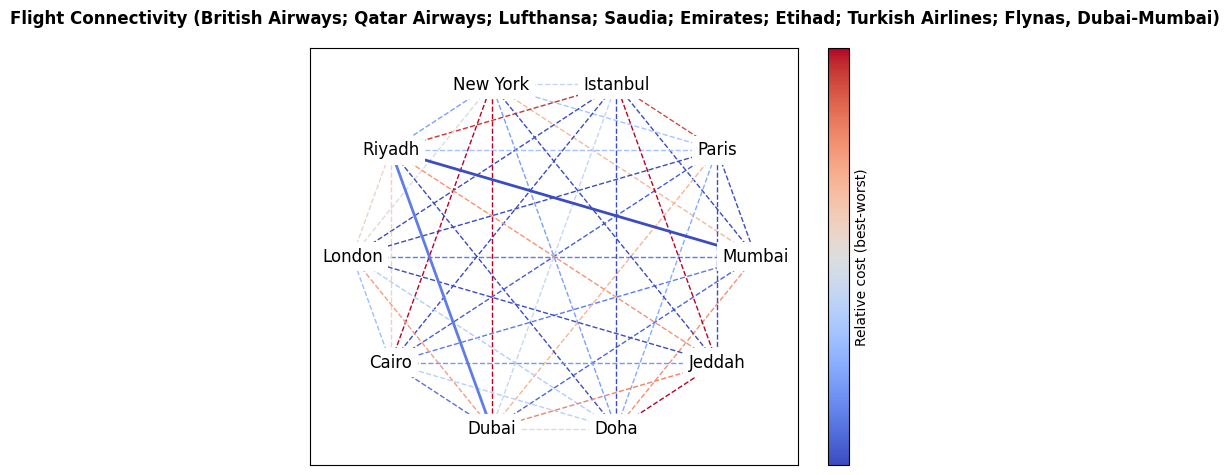

In [12]:
# @title **Visualise flight connectivity**
# @markdown Draw a graph of the shortest path generated and all other
# @markdown possibilities. If your path uses the directed graph, it may appear
# @markdown suboptimal, but that is not the case.

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sys import maxsize as MAX_INT

# constants
class_mapping = {"Economy": 0.9, "Business": 0.1, "First": 0.0}
ALPHA = 0.2
BETA = 0.1
GAMMA = 0.7
assert ALPHA + BETA + GAMMA == 1.0

# init figure
fig, ax = plt.subplots()
graph = nx.Graph()

def cost_function(distance, flight_class, price):
    return (ALPHA*distance +
            BETA*float(class_mapping[flight_class]) +
            GAMMA*price)

def calculate_cost(options: list[list[str]], restriction: list
                   ) -> tuple[str | None, float]:
    """
    Calculates cost of a given edge.

    args:
        options (list):     metadata associated with edge
        restriction (list): airline restrictions

    returns:
        min_cost (tuple):   minimum cost of that edge found in dataset
    """
    min_cost = (None, MAX_INT)
    for (airline, dist, flight, price) in options:
        if airline in restriction:
            cost = cost_function(float(dist), flight, float(price))
            if cost < min_cost[1]: min_cost = (airline, cost)
    return min_cost

def plot_connectivity(airlines: list, path_taken: list[tuple[str, str]]):
    journeys = directed_journeys if directed else undirected_journeys

    # convert path taken to edge format
    visited = [loc[0] for loc in path_taken]
    path = list(zip(visited[:-1], visited[1:]))

    # add edges
    edges = {}
    for loc0 in journeys.keys():
        for loc1 in journeys[loc0].keys():
            options = journeys[loc0][loc1]
            weight = calculate_cost(options, airlines)
            if weight[0] is None: continue
            edges[(loc0, loc1)] = weight
    max_w, min_w = max(edges.values())[1], min(edges.values())[1]
    for ((x0, x1), x2) in edges.items():
        graph.add_edge(x0, x1, weight=((x2[1]-min_w)/(max_w-min_w)))

    # plot
    cmap = plt.get_cmap("coolwarm")
    edge_colours = [cmap(edge[2]["weight"]) for edge in graph.edges(data=True)
                    if edge[:2][::-1] not in path
                    or ((not directed) and edge[:2] not in path)]
    path_colours = [cmap(edge[2]["weight"]) for edge in graph.edges(data=True)
                    if edge[:2][::-1] in path
                    or ((not directed) and edge[:2] in path)]
    layout = nx.circular_layout(graph)
    nx.draw_networkx_nodes(graph, layout, node_color="white")
    nx.draw_networkx_labels(graph, layout, bbox={"facecolor": "white",
                                                 "linewidth": 0})
    E = nx.draw_networkx_edges(graph, layout,
                        edgelist=[(u,v) for (u,v,d) in graph.edges(data=True)
                                  if (u,v) not in path and (v,u) not in path],
                        edge_color=edge_colours, edge_cmap=cmap, style="--")
    Ex = nx.draw_networkx_edges(graph, layout, edgelist=path,
                           edge_color=path_colours, edge_cmap=cmap, style="-",
                           width=2)
    plt.colorbar(E, label="Relative cost (best-worst)", ticks=[])
    fig.suptitle(f"Flight Connectivity ({"; ".join(airlines)}, {path[0][0]}-{path[-1][1]})", fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_connectivity(airlines, path) # this takes last global path from dijkstra

In [13]:
# @title **Run functional unit tests**
# @markdown Expand this cell for test details.

try:

    # NY -> Doha (all airlines, undirected)
    # dense graph with lots of tradeoffs
    p0, c0 = dijkstra_search("New York", "Doha", [_ for _ in AIRLINE_NAMES], False)
    print(f"Test case 1: {"PASS" if c0 == 740.7919999999999 and len(p0) == 4 else "FAIL"}")

    # NY -> Jeddah (British Airways, directed)
    # checking if single connection works
    p1, c1 = dijkstra_search("New York", "Jeddah", ["British Airways"], True)
    print(f"Test case 2: {"PASS" if c1 == 4872.018 and len(p1) == 2 else "FAIL"}")

    # Jeddah -> NY (British Airways, directed)
    # checking if it can find a good alternative route
    p2, c2 = dijkstra_search("Jeddah", "New York", ["British Airways"], True)
    print(f"Test case 3: {"PASS" if c2 == 9799.902 and len(p2) == 4 else "FAIL"}")

    # Jeddah -> NY (British Airways, undirected)
    # checking if edges can be taken backwards when undirected
    p3, c3 = dijkstra_search("Jeddah", "New York", ["British Airways"], False)
    print(f"Test case 4: {"PASS" if c3 == 4872.018 and len(p3) == 2 else "FAIL"}")

    # London -> New York (Etihad, directed)
    # checking if impossible routes are identified
    try:
        p4, c4 = dijkstra_search("London", "New York", ["Etihad"], True)
        print("Test case 5: FAIL")
    except:
        print("Test case 5: PASS")

    # London -> New York (Etihad, undirected)
    # checking if the undirected version of an impossible route is found
    p5, c5 = dijkstra_search("London", "New York", ["Etihad"], False)
    print(f"Test case 6: {"PASS" if c5 == 4041.786 and len(p5) == 4 else "FAIL"}")

except NameError:
    print("Run the main algorithm cell first.")

Test case 1: PASS
Test case 2: PASS
Test case 3: PASS
Test case 4: PASS
Test case 5: PASS
Test case 6: PASS


Additionally, the user input is sanitised as follows:

1. The source and destination airports are only accepted if they match the airport names given (case sensitive). The destination airport cannot be the same as the source airport, as this would not require a flight.
```python
source, destination = "", ""
while source not in locations:
    source = input("Source airport: ")
while destination not in locations or destination == source:
    destination = input("Destination airport: ")
```

2. The airline input can be given in multiple ways:
- **by pressing enter:** this automatically selects the default option, which is all airlines
- **by entering "ALL":** this selects all airlines, overriding any previous inputs
- **by entering one or more airline names, then pressing enter:** this adds all (unique) airlines to the filter list, provided they match a known entry
```python
airlines = []
while True:
    inp = input("'ALL', Airline, or enter to finish: ")
    if inp.upper() == "ALL" or (len(inp) == 0 and len(airlines) == 0):
        airlines = [_ for _ in AIRLINE_NAMES]
        break
    elif inp in AIRLINE_NAMES and inp not in airlines: airlines.append(inp)
    elif len(inp) == 0: break
    elif inp not in airlines: print("Error: Invalid airline.")
```

3. The graph is always assumed to be undirected, regardless of the input, unless `n` is entered.
```python
directed = False if (input("Directed? (Y/n): ") == "n") else True
```

4. The function call is wrapped in a `try` block, as if no valid path is found, an exception is raised.
```python
try:
    path, cost = dijkstra_search(source, destination, airlines, directed)
    print(f"Path ({"directed" if directed else "undirected"}): " + f"{', '.join([f'{x} ({y})' for x, y in path])}")
    print(f"Total cost: {cost}")
except Exception: print(f"Error: Invalid path request (no path found).\nTry undirected?")
```